## ● Churn Prediction – Predict customer attrition using real-world datasets.

### 1. IMPORTS LIBRARIES

In [1]:
# impot libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### 2. LOAD DATASET

In [2]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Quick overview
print(f"Shape: {df.shape}")        
print(f"Columns: {list(df.columns)}")
print(df.head())

# Target distribution
print("--- Churn Distribution ---")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3) * 100, "%")

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1               

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges: blank strings - NaN - float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values
print("Missing values:", df.isnull().sum()[df.isnull().sum() > 0])

# Drop rows with NaN 
df.dropna(inplace=True)
print(f"Shape after cleaning: {df.shape}")

# Check duplicates
print(f"Duplicates: {df.duplicated().sum()}")

# Encode target: Yes - 1, No - 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"Churn encoded: {df['Churn'].unique()}")

Missing values: TotalCharges    11
dtype: int64
Shape after cleaning: (7032, 20)
Duplicates: 22
Churn encoded: [0 1]


In [5]:
print('check costumerID column whether its drop or not.')
df

check costumerID column whether its drop or not.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


## Exploratory Data Analysis (EDA)

Visualize customer churn patterns and analyze relationships between important features.

This step includes:
- Examining the overall churn distribution
- Analyzing tenure distribution by churn status
- Comparing churn rates across contract types
- Exploring correlations between numerical features using a heatmap

Key insights:
- Customers with month-to-month contracts show higher churn rates.
- Customers with lower tenure are more likely to churn.
- Certain service and payment patterns are associated with higher churn.
- Correlation analysis helps identify relationships between numerical variables.

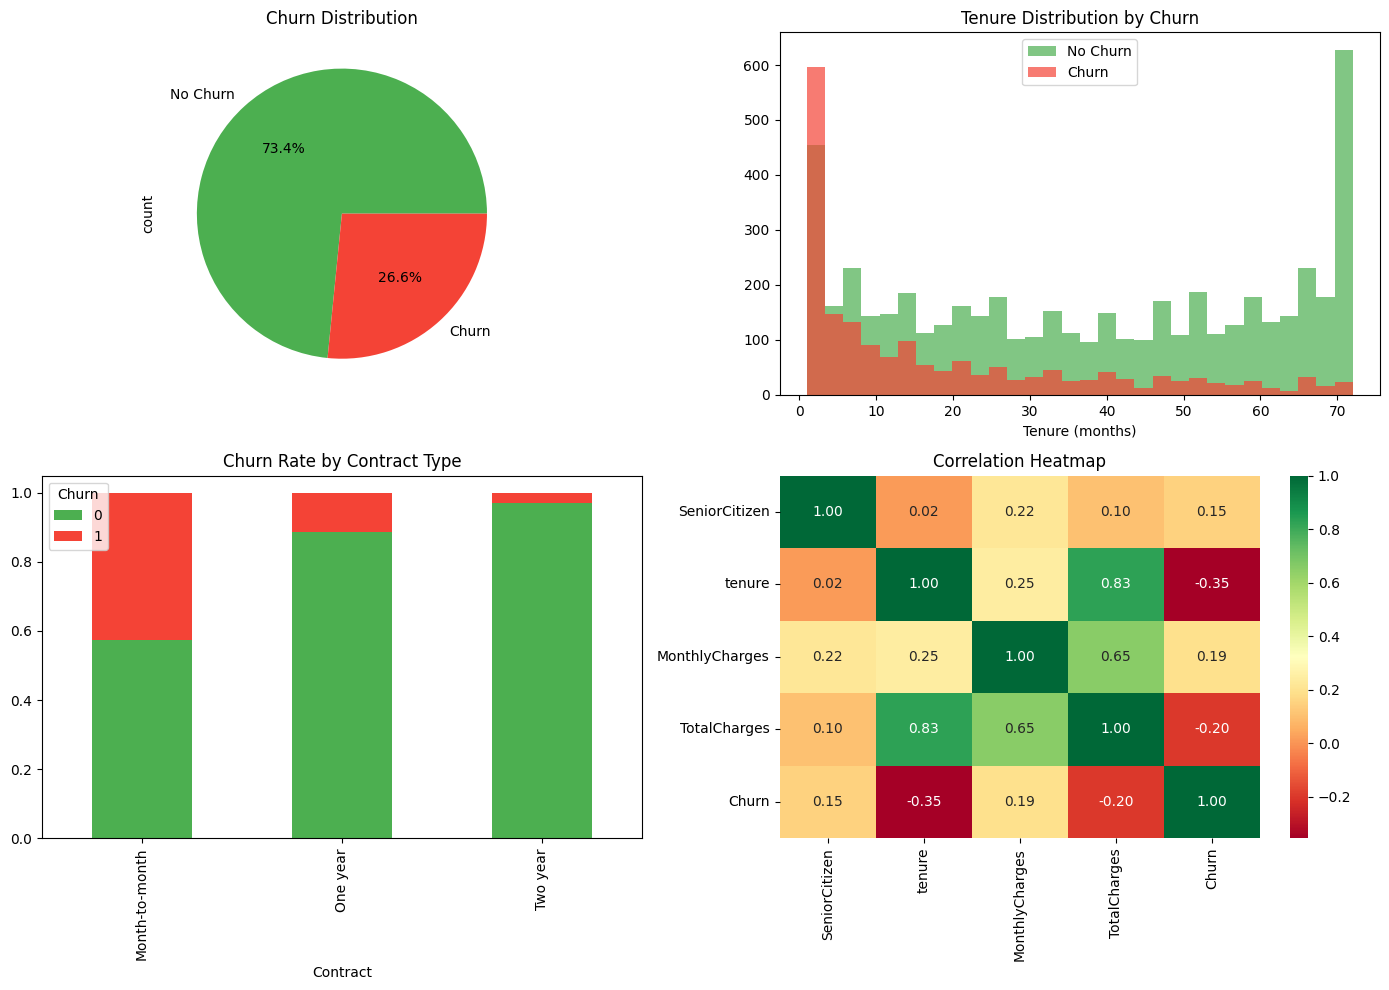

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn distribution (pie)
df['Churn'].value_counts().plot.pie(
    ax=axes[0,0], autopct='%1.1f%%',
    labels=['No Churn', 'Churn'], colors=['#4CAF50', '#F44336']
)
axes[0,0].set_title('Churn Distribution')

# 2. Tenure histogram — fixed: loop over groups
colors = ['#4CAF50', '#F44336']
labels = ['No Churn', 'Churn']
for (churn_val, group), color, label in zip(
        df.groupby('Churn')['tenure'], colors, labels):
    axes[0,1].hist(group, bins=30, alpha=0.7, color=color, label=label)
axes[0,1].set_title('Tenure Distribution by Churn')
axes[0,1].set_xlabel('Tenure (months)')
axes[0,1].legend()

# 3. Churn by Contract type
pd.crosstab(df['Contract'], df['Churn'], normalize='index').plot(
    kind='bar', ax=axes[1,0], stacked=True,
    color=['#4CAF50', '#F44336']
)
axes[1,0].set_title('Churn Rate by Contract Type')

# 4. Correlation heatmap — fixed: plain df.select_dtypes
sns.heatmap(df.select_dtypes(include='number').corr(),
           ax=axes[1,1], annot=True, fmt='.2f', cmap='RdYlGn')
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

## Feature Engineering

Encode categorical variables and create new meaningful features to improve model performance.

This step includes:
- Converting binary Yes/No columns into numeric format (0 and 1)
- Creating new features such as:
  - `TotalServices`
  - `ChargesPerMonth`
- Applying one-hot encoding to multi-class categorical variables using `get_dummies()`

Feature engineering helps machine learning models better capture customer behavior and service usage patterns.

In [7]:
# Encode binary Yes/No columns 
binary_cols = ['Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'gender']

for col in binary_cols:
    if col in df.columns:
        df[col] = (df[col] == 'Yes').astype(int)

# Create new features (BEFORE get_dummies)
df['TotalServices'] = (
    df['PhoneService'] +
    df['PaperlessBilling'] +
    (df['MultipleLines'] == 'Yes').astype(int)
)

df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

# One-hot encode multi-class columns (LAST)
cat_cols = ['InternetService', 'Contract', 'PaymentMethod',
            'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies']

# Only encode columns that exist
cat_cols = [c for c in cat_cols if c in df.columns]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f" Done! Features: {df.shape[1] - 1}  |  Rows: {df.shape[0]}")
print(f"Churn column still present: {'Churn' in df.columns}")

 Done! Features: 32  |  Rows: 7032
Churn column still present: True


## Train-Test Split and Feature Scaling

Split the dataset into training and testing sets while preserving class distribution, and scale features for machine learning models.

This step includes:
- Separating features (`X`) and target (`y`)
- Performing an 80/20 stratified train-test split
- Applying feature scaling using `StandardScaler`

Stratified splitting ensures that both training and testing sets maintain the same churn class distribution, which is important for imbalanced classification problems.

Feature scaling is especially important for algorithms such as Logistic Regression, as it normalizes feature values and improves model performance.

In [8]:
# TRAIN / TEST SPLIT 

X = df.drop('Churn', axis=1)
y = df['Churn']

# Stratified split preserves class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y         # important for imbalanced classes
)

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"Churn in train: {y_train.mean():.2%}")
print(f"Churn in test:  {y_test.mean():.2%}")

# Feature scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # only transform, never fit!

Training set:  (5625, 32)
Test set:      (1407, 32)
Churn in train: 26.58%
Churn in test:  26.58%


## Model Training

Train multiple classification models to predict customer churn and compare their performance.

This step includes training the following models:
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier

Logistic Regression uses scaled data, while tree-based models use raw data.

The models are evaluated using:
- Accuracy
- ROC-AUC score

Tree-based models often perform better on this dataset due to their ability to capture non-linear relationships between features.## 7. Model Training
Train multiple classification models and compare them

Logistic Regression, 
Random Forest, 
Gradient Boosting

We train 3 models simultaneously. Random Forest and Gradient Boosting typically outperform Logistic Regression on this dataset due to non-linear feature interactions.

In [9]:
# MODEL TRAINING 

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    # Use scaled data for Logistic Regression, raw for tree models
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_prob),
        'model':    model
    }
    print(f"{name:25} Acc: {results[name]['accuracy']:.4f} | AUC: {results[name]['roc_auc']:.4f}")

Logistic Regression       Acc: 0.8003 | AUC: 0.8380
Decision Tree             Acc: 0.7235 | AUC: 0.6560
Random Forest             Acc: 0.7960 | AUC: 0.8188
Gradient Boosting         Acc: 0.7989 | AUC: 0.8407


## Model Evaluation

Evaluate the best-performing model (Gradient Boosting) using multiple performance metrics.

This step includes:
- Classification report (Precision, Recall, F1-score)
- Confusion matrix to analyze prediction errors
- ROC curve to evaluate model performance across thresholds
- AUC-ROC score as the primary evaluation metric for churn prediction

AUC-ROC is more important than accuracy for churn problems because the dataset is imbalanced. A model predicting only "No Churn" could still achieve high accuracy but would have very poor AUC, making it useless for business decisions.

=== Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1033
       Churn       0.65      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



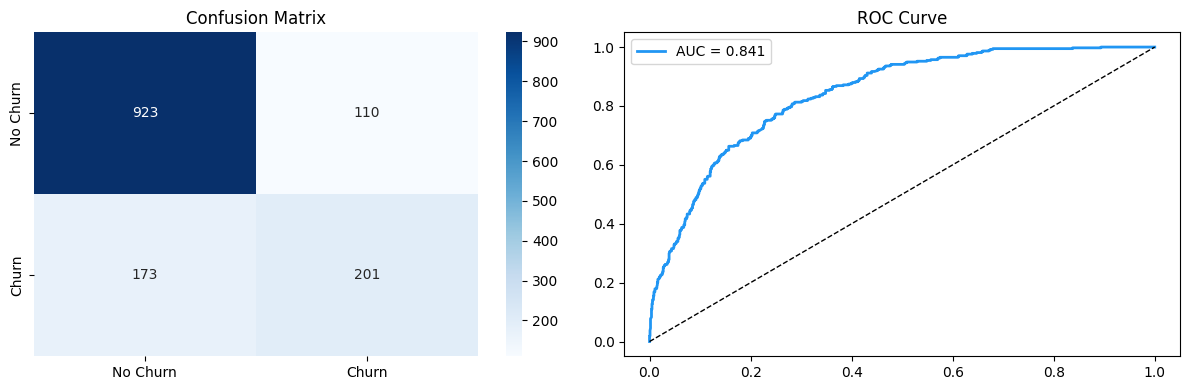

In [10]:
# MODEL EVALUATION 

# Best model: Gradient Boosting
best_model = results['Gradient Boosting']['model']
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# 1. Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred_best,
      target_names=['No Churn', 'Churn']))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['No Churn','Churn'],
           yticklabels=['No Churn','Churn'], ax=axes[0])
axes[0].set_title('Confusion Matrix')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc = roc_auc_score(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='#2196F3', lw=2,
             label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_title('ROC Curve')
axes[1].legend()
plt.tight_layout()
plt.show()

## Feature Importance

Identify the most important features that influence customer churn predictions using the trained Gradient Boosting model.

This step includes:
- Extracting feature importance scores from the model
- Ranking features based on their impact
- Visualizing the top 10 most important features
- Displaying feature importance values for interpretation

Key business insights:
The most influential factors for churn typically include contract type, customer tenure, monthly charges, and internet service type. These insights can help businesses design better customer retention strategies.

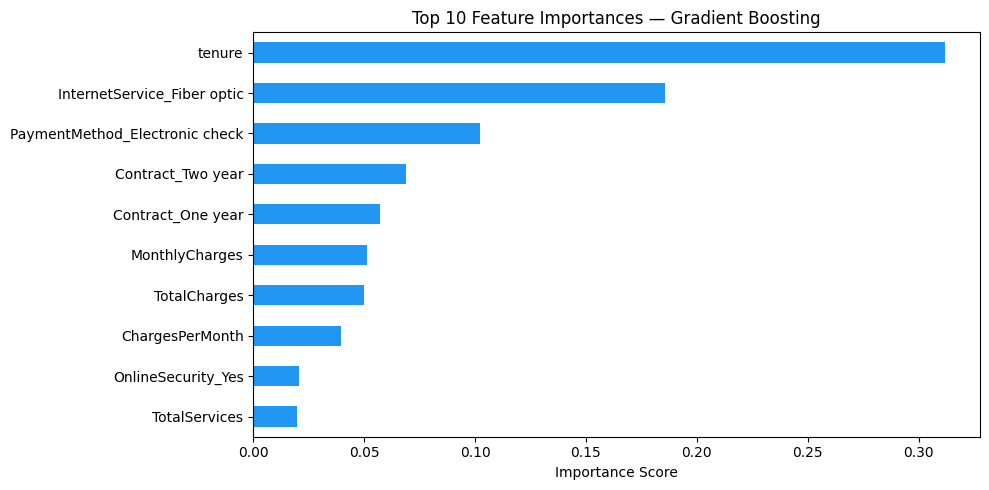

=== Top 10 Churn Predictors ===
  tenure                              0.3120
  InternetService_Fiber optic         0.1858
  PaymentMethod_Electronic check      0.1022
  Contract_Two year                   0.0689
  Contract_One year                   0.0573
  MonthlyCharges                      0.0513
  TotalCharges                        0.0501
  ChargesPerMonth                     0.0396
  OnlineSecurity_Yes                  0.0207
  TotalServices                       0.0198


In [11]:
# FEATURE IMPORTANCE 

# Get feature importances from Gradient Boosting
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plot top 10 features
top_features = feat_imp.head(10)

plt.figure(figsize=(10, 5))
top_features.plot(kind='barh', color='#2196F3')
plt.title('Top 10 Feature Importances — Gradient Boosting')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("=== Top 10 Churn Predictors ===")
for feat, score in top_features.items():
    print(f"  {feat:35} {score:.4f}")

## Predict and Deploy

Create a reusable machine learning pipeline and make predictions on new customer data. The trained model is then saved for future use.

This step includes:
- Building a scikit-learn Pipeline combining preprocessing and the model
- Training the pipeline on the full training dataset
- Making predictions on unseen customer data
- Estimating churn probabilities using `predict_proba`
- Saving the trained pipeline using `joblib` for deployment

Using a pipeline ensures that the same preprocessing steps are automatically applied to any new incoming data, making the model production-ready.

In [12]:
# PREDICT NEW CUSTOMERS & SAVE PIPELINE 
import joblib

# Build a full reusable Pipeline (scaler + model)
full_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  GradientBoostingClassifier(n_estimators=100, random_state=42))
])

full_pipeline.fit(X_train, y_train)

# Predict on new customer data
new_customer = X_test.iloc[0:3]   # simulate 3 new customers

predictions  = full_pipeline.predict(new_customer)
churn_probs  = full_pipeline.predict_proba(new_customer)[:, 1]

for i, (pred, prob) in enumerate(zip(predictions, churn_probs)):
    status = "🔴 CHURN RISK" if pred == 1 else "🟢 RETAINED"
    print(f"Customer {i+1}: {status}  (probability: {prob:.1%})")

# Save the pipeline 
joblib.dump(full_pipeline, 'churn_pipeline.pkl')
print("Model saved as 'churn_pipeline.pkl'")

# ── Load & use later ──────────────────────────────────────
# loaded_model = joblib.load('churn_pipeline.pkl')
# loaded_model.predict(new_data)

Customer 1: 🟢 RETAINED  (probability: 2.5%)
Customer 2: 🔴 CHURN RISK  (probability: 54.4%)
Customer 3: 🟢 RETAINED  (probability: 2.3%)
Model saved as 'churn_pipeline.pkl'
